# Descarga del dataset y EDA

Este notebook baja **Book Spine 2** (Roboflow) a `dataset/` en la raíz del repo, en formato YOLOv8. Si esa carpeta ya tiene `data.yaml` e imágenes, **no vuelve a descargar**. Si no está, hace falta una API key de Roboflow.

### Cómo conseguir la API key

1. Creá una cuenta gratis en [Roboflow](https://app.roboflow.com/).
2. Entrá a **Settings → API Keys** (o [Account → API](https://app.roboflow.com/settings/api)).
3. Copiá la **Private API Key**. Sirve para bajar datasets públicos de Universe; no hace falta ser dueño del proyecto *Book Spine 2*.

### Cómo usarla (nunca en el notebook ni en git)

La celda de descarga busca `ROBOFLOW_API_KEY` en este orden y **no imprime** el valor:

1. **Variable de entorno** (local o Colab):
   ```bash
   export ROBOFLOW_API_KEY=rf_xxxxx
   ```
2. **Archivo `.env`** en la raíz del repo (está en `.gitignore`):
   ```
   ROBOFLOW_API_KEY=rf_xxxxx
   ```
3. **Secret de Colab** con el nombre exacto `ROBOFLOW_API_KEY` (ícono de llave a la izquierda → Add new secret).
4. Si no hay ninguna de las anteriores, al ejecutar la celda **getpass** pide la key en silencio.

No la escribas en una celda ni en un archivo versionado. Si se filtra, revocala en Roboflow y generá otra.



## 1. Setup - Instalación de `roboflow`

Esta celda instala el paquete `roboflow` en el kernel de este notebook (`%pip`). Es la única celda que instala librerías.

No baja el dataset ni pide la API key. Si el kernel avisa que hay que reiniciarlo para usar el paquete, reiniciá y volvé a ejecutar esta celda antes de seguir.


In [2]:
%pip install -q roboflow


Note: you may need to restart the kernel to use updated packages.


## 2. Descarga de Book Spine 2

Esta celda pone el dataset en `dataset/` (raíz del repo), export YOLOv8, última versión publicada de `bookspine-fxfsx/book_spine_2`.

- Si ya hay `data.yaml` e imágenes, **no descarga**.
- Si falta, usa `ROBOFLOW_API_KEY` como se indicó arriba (env, `.env`, secret de Colab o `getpass`). No imprime la key.
- Si `dataset/` existe pero está incompleta (por ejemplo vacía), **sí descarga** (`overwrite`), porque el SDK de Roboflow no baja nada cuando la carpeta ya existe.

Hace falta haber corrido la celda de instalación. Al terminar deberías ver un conteo de imágenes y la carpeta `dataset/train` (y `valid`/`test` si el export las trae).


In [4]:
import os
from getpass import getpass
from pathlib import Path

from roboflow import Roboflow

ESPACIO_ROBOFLOW = "bookspine-fxfsx"
PROYECTO_ROBOFLOW = "book_spine_2"
FORMATO_EXPORTACION = "yolov8"
PATRONES_IMAGEN = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp")


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def cargar_variables_entorno(ruta: Path) -> None:
    if not ruta.is_file():
        return
    for linea in ruta.read_text(encoding="utf-8").splitlines():
        linea = linea.strip()
        if not linea or linea.startswith("#") or "=" not in linea:
            continue
        clave, _, valor = linea.partition("=")
        os.environ.setdefault(clave.strip(), valor.strip().strip("'").strip('"'))


def clave_api_roboflow() -> str:
    clave = os.environ.get("ROBOFLOW_API_KEY", "").strip()
    if clave:
        return clave
    try:
        from google.colab import userdata

        clave = (userdata.get("ROBOFLOW_API_KEY") or "").strip()
        if clave:
            os.environ["ROBOFLOW_API_KEY"] = clave
            return clave
    except Exception:
        pass
    clave = getpass("Pegá la API key de Roboflow (no se muestra): ").strip()
    if not clave:
        raise RuntimeError(
            "Falta ROBOFLOW_API_KEY. Configurala como env, .env o secret de Colab."
        )
    os.environ["ROBOFLOW_API_KEY"] = clave
    return clave


def dataset_listo(ruta: Path) -> bool:
    if not ruta.is_dir():
        return False
    tiene_yaml = any(ruta.rglob("data.yaml"))
    n_imagenes = sum(1 for patron in PATRONES_IMAGEN for _ in ruta.rglob(patron))
    return tiene_yaml and n_imagenes > 0


def id_ultima_version(proyecto) -> int:
    versiones = proyecto.versions()
    if not versiones:
        raise RuntimeError(
            f"El proyecto {PROYECTO_ROBOFLOW} no tiene versiones publicadas."
        )
    identificadores = []
    for version in versiones:
        crudo = getattr(version, "version", None)
        if crudo is None:
            continue
        identificadores.append(int(str(crudo).split(".")[0]))
    if identificadores:
        return max(identificadores)
    return int(str(versiones[0].version).split(".")[0])


RAIZ = raiz_del_repo()
DIRECTORIO_DATASET = RAIZ / "dataset"
cargar_variables_entorno(RAIZ / ".env")

print(f"Repo: {RAIZ}")
print(f"Dataset: {DIRECTORIO_DATASET}")

if dataset_listo(DIRECTORIO_DATASET):
    n_imagenes = sum(
        1 for patron in PATRONES_IMAGEN for _ in DIRECTORIO_DATASET.rglob(patron)
    )
    print(
        f"El dataset ya está en {DIRECTORIO_DATASET} ({n_imagenes} imágenes). No se descarga."
    )
else:
    cliente = Roboflow(api_key=clave_api_roboflow())
    proyecto = cliente.workspace(ESPACIO_ROBOFLOW).project(PROYECTO_ROBOFLOW)
    id_version = id_ultima_version(proyecto)
    # El SDK de Roboflow no descarga si `location` ya existe y overwrite=False
    # (aunque la carpeta esté vacía). Sobrescribir solo si el dataset no está listo.
    sobrescribir = DIRECTORIO_DATASET.exists()
    print(
        f"Descargando {ESPACIO_ROBOFLOW}/{PROYECTO_ROBOFLOW} v{id_version} ({FORMATO_EXPORTACION})…"
    )
    proyecto.version(id_version).download(
        FORMATO_EXPORTACION,
        location=str(DIRECTORIO_DATASET),
        overwrite=sobrescribir,
    )
    if not dataset_listo(DIRECTORIO_DATASET):
        raise RuntimeError(
            f"La descarga terminó pero no hay data.yaml + imágenes en {DIRECTORIO_DATASET}."
        )
    n_imagenes = sum(
        1 for patron in PATRONES_IMAGEN for _ in DIRECTORIO_DATASET.rglob(patron)
    )
    print(f"Listo: {DIRECTORIO_DATASET} ({n_imagenes} imágenes).")


Repo: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/02. Vision x Computadora/Materias/04. Vision por Computadora 2/mi-repo/DVxC-VcCII-TP-evaluacion
Dataset: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/02. Vision x Computadora/Materias/04. Vision por Computadora 2/mi-repo/DVxC-VcCII-TP-evaluacion/dataset
loading Roboflow workspace...
loading Roboflow project...
Descargando bookspine-fxfsx/book_spine_2 v4 (yolov8)…



Extracting Dataset Version Zip to /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/02. Vision x Computadora/Materias/04. Vision por Computadora 2/mi-repo/DVxC-VcCII-TP-evaluacion/dataset in yolov8:: 100%|██████████| 3324/3324 [00:00<00:00, 6615.54it/s]

Listo: /Users/marcelo.luna/Library/CloudStorage/OneDrive-Personal/Diplomaturas/02. Vision x Computadora/Materias/04. Vision por Computadora 2/mi-repo/DVxC-VcCII-TP-evaluacion/dataset (1656 imágenes).


## 3. Análisis del Dataset

### 3.1 Análisis de los datos — distribución por partición

Esta celda cuenta las imágenes de **entrenamiento**, **validación** y **prueba** en `dataset/` (`train/images`, `valid/images`, `test/images`) y las muestra en un gráfico de barras, con cantidad y porcentaje sobre el total.

No descarga datos ni lee etiquetas: solo describe cómo está partido el set. Requiere `dataset/` completo y matplotlib.



Imágenes por partición
---------------------
Entrenamiento    1265  ( 76.4 %)
Validación        271  ( 16.4 %)
Prueba            120  (  7.2 %)
Total            1656  (100.0 %)


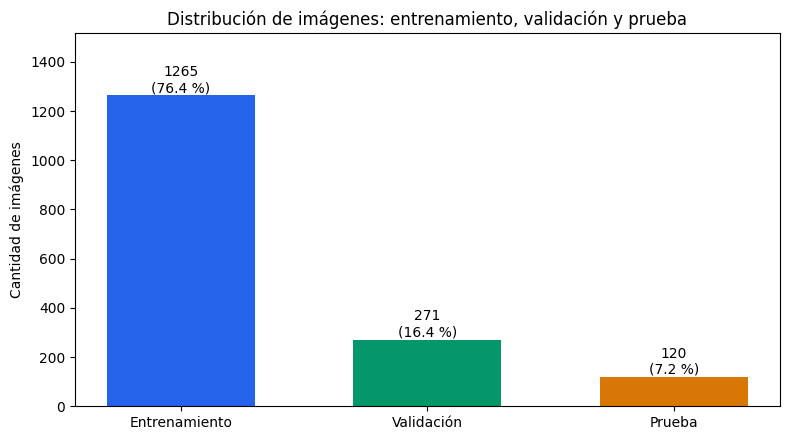

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt

EXTENSIONES_IMAGEN = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
PARTICIONES = (
    ("train", "Entrenamiento"),
    ("valid", "Validación"),
    ("test", "Prueba"),
)


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def contar_imagenes(directorio: Path) -> int:
    if not directorio.is_dir():
        return 0
    return sum(
        1
        for archivo in directorio.iterdir()
        if archivo.is_file() and archivo.suffix.lower() in EXTENSIONES_IMAGEN
    )


directorio_dataset = None
try:
    directorio_dataset = DIRECTORIO_DATASET
except NameError:
    directorio_dataset = raiz_del_repo() / "dataset"

if not directorio_dataset.is_dir():
    raise FileNotFoundError(
        f"No está {directorio_dataset}. Ejecutá antes la celda de descarga."
    )

nombres = []
conteos = []
for carpeta, etiqueta in PARTICIONES:
    cantidad = contar_imagenes(directorio_dataset / carpeta / "images")
    nombres.append(etiqueta)
    conteos.append(cantidad)
    if cantidad == 0:
        print(f"Aviso: no hay imágenes en {carpeta}/images")

total = sum(conteos)
if total == 0:
    raise RuntimeError(f"No se encontraron imágenes en {directorio_dataset}.")

print("Imágenes por partición")
print("---------------------")
for etiqueta, cantidad in zip(nombres, conteos):
    porcentaje = 100 * cantidad / total
    print(f"{etiqueta:15} {cantidad:5d}  ({porcentaje:5.1f} %)")
print(f"{'Total':15} {total:5d}  (100.0 %)")

figura, eje = plt.subplots(figsize=(8, 4.5))
colores = ("#2563eb", "#059669", "#d97706")
barras = eje.bar(nombres, conteos, color=colores, width=0.6)
eje.set_ylabel("Cantidad de imágenes")
eje.set_title("Distribución de imágenes: entrenamiento, validación y prueba")
eje.set_ylim(0, max(conteos) * 1.2)
for barra, cantidad in zip(barras, conteos):
    porcentaje = 100 * cantidad / total
    eje.text(
        barra.get_x() + barra.get_width() / 2,
        barra.get_height(),
        f"{cantidad}\n({porcentaje:.1f} %)",
        ha="center",
        va="bottom",
    )
figura.tight_layout()
plt.show()


### Lectura del split

El corte es ~76 / 16 / 7 % (1.265 / 271 / 120 imágenes). Hay una sola clase y ~26.700 lomos; validación y prueba tienen una densidad parecida a entrenamiento (~15–17 lomos por foto). El volumen alcanza para un fine-tuning de detección. Conviene medir sobre validación y dejar test como chequeo final, sin ajustar hiperparámetros ahí.

**Limitaciones**

- Test es chico en *fotos* (120): el mAP de prueba será más ruidoso que el de validación.
- Muchos objetos chicos y juntos: las cajas pueden fallar o fusionar lomos vecinos.
- Estas fotos no cubren cualquier estantería real (ángulo, luz, recorte vs. estante completo).
- Hay unas 20 imágenes casi vacías en train: poco peso estadístico.
- Este split no mide si se lee el texto del lomo: hace falta un subconjunto con transcripción.



### 3.2 Por qué no histogramas RGB ni t-SNE

Un EDA genérico suele arrancar con color o con una proyección de las imágenes. Para **detección de lomos** eso no indica si las etiquetas sirven.

- **RGB:** localizar un lomo no depende de que el estante sea más claro o más saturado. Dos fotos con histogramas distintos pueden tener el mismo problema geométrico (lomos finos y juntos). El color no predice el mAP ni la calidad de un recorte.
- **t-SNE (u otras proyecciones de píxeles):** resume cada foto en un punto. Con ~16 lomos por imagen, ese punto mezcla libros, fondo y cámara. No separa lomo chico, torcido o tapado, que es lo que suele fallar en detección.

El dataset tiene **una sola clase** y etiquetas **polígono**. YOLOv8 y Faster R-CNN usan **cajas alineadas a los ejes**. Lo que importa es la geometría de cada lomo y la diferencia entre máscara y caja (ocupación, tamaño, inclinación, solape).



### 3.3 Polígono vs. caja (ocupación)

YOLOv8 y Faster R-CNN no usan el polígono del lomo: usan una **caja alineada a los ejes** (AABB) que envuelve esos puntos. Si el lomo está torcido, la caja se agranda y mete al vecino o al fondo. Eso puede afectar poco al mAP y mucho a un recorte para OCR.

**Qué se mide:** ocupación = área del polígono / área de la caja.

- Cerca de **1**: la caja ajusta al lomo.
- **Baja**: gran parte de la caja no es el lomo.

Se calcula sobre **validación**. Un histograma resume todas las instancias; la galería muestra 6 fotos: las 2 de peor ocupación media, 2 del medio y 2 de las mejores. Verde = polígono; rojo = caja.

No es calidad del anotador ni un mAP: indica cuánta holgura extra tiene la caja respecto de la máscara.



Partición: valid
Instancias: 4622
Imágenes con al menos un lomo: 269
Ocupación (área polígono / área caja)
  media   0.543
  mediana 0.530
  p10     0.184
  p90     0.918


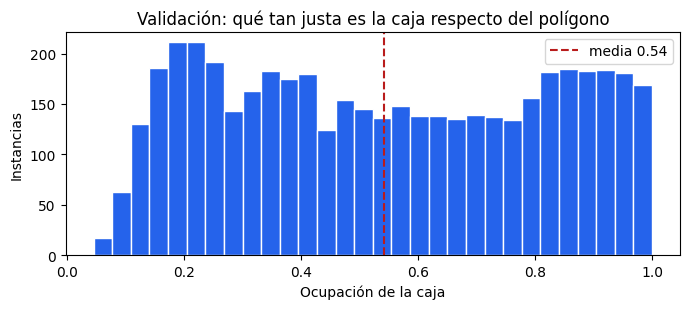

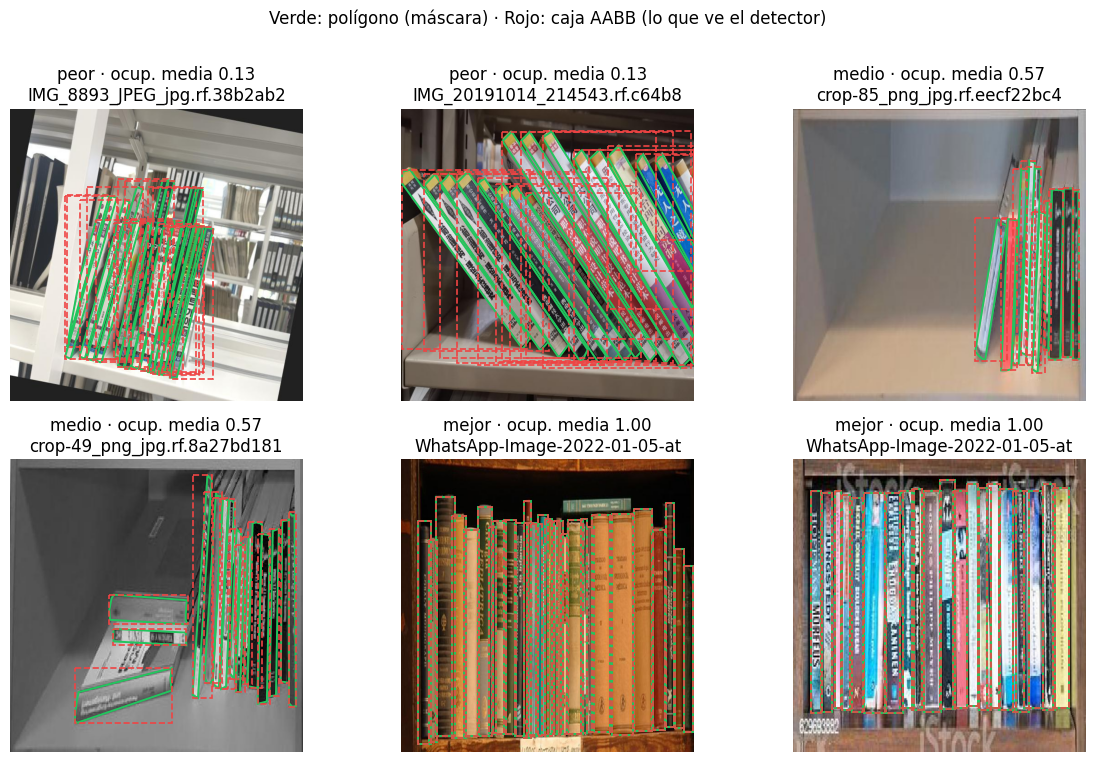

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon, Rectangle
from PIL import Image

PARTICION = "valid"
EXTENSIONES_IMAGEN = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def poligono_desde_linea(linea: str) -> np.ndarray | None:
    partes = linea.split()
    if len(partes) < 7:
        return None
    valores = np.array([float(p) for p in partes[1:]], dtype=float)
    if valores.size % 2 != 0 or valores.size < 6:
        return None
    return valores.reshape(-1, 2)


def area_poligono(vertices: np.ndarray) -> float:
    x = vertices[:, 0]
    y = vertices[:, 1]
    return 0.5 * float(np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1))))


def caja_xyxy(vertices: np.ndarray) -> tuple[float, float, float, float]:
    xmin, ymin = vertices.min(axis=0)
    xmax, ymax = vertices.max(axis=0)
    return float(xmin), float(ymin), float(xmax), float(ymax)


def ocupacion_caja(vertices: np.ndarray) -> float:
    xmin, ymin, xmax, ymax = caja_xyxy(vertices)
    area_caja = max(xmax - xmin, 1e-12) * max(ymax - ymin, 1e-12)
    return float(np.clip(area_poligono(vertices) / area_caja, 0.0, 1.0))


def instancias_de_etiqueta(ruta_txt: Path) -> list[np.ndarray]:
    poligonos = []
    for linea in ruta_txt.read_text(encoding="utf-8").splitlines():
        linea = linea.strip()
        if not linea or linea.startswith("#"):
            continue
        poligono = poligono_desde_linea(linea)
        if poligono is not None:
            poligonos.append(poligono)
    return poligonos


try:
    directorio_dataset = DIRECTORIO_DATASET
except NameError:
    directorio_dataset = raiz_del_repo() / "dataset"

directorio_imagenes = directorio_dataset / PARTICION / "images"
directorio_etiquetas = directorio_dataset / PARTICION / "labels"
if not directorio_imagenes.is_dir() or not directorio_etiquetas.is_dir():
    raise FileNotFoundError(f"Falta {PARTICION}/images o labels en {directorio_dataset}.")

ocupaciones = []
resumen_por_imagen = []
for ruta_imagen in sorted(directorio_imagenes.iterdir()):
    if ruta_imagen.suffix.lower() not in EXTENSIONES_IMAGEN:
        continue
    ruta_txt = directorio_etiquetas / f"{ruta_imagen.stem}.txt"
    if not ruta_txt.is_file():
        continue
    poligonos = instancias_de_etiqueta(ruta_txt)
    if not poligonos:
        continue
    ocup_img = [ocupacion_caja(p) for p in poligonos]
    ocupaciones.extend(ocup_img)
    resumen_por_imagen.append(
        {
            "ruta": ruta_imagen,
            "poligonos": poligonos,
            "media": float(np.mean(ocup_img)),
        }
    )

if not ocupaciones:
    raise RuntimeError(f"No hay polígonos YOLO en {directorio_etiquetas}.")

ocupaciones = np.array(ocupaciones, dtype=float)
print(f"Partición: {PARTICION}")
print(f"Instancias: {len(ocupaciones)}")
print(f"Imágenes con al menos un lomo: {len(resumen_por_imagen)}")
print("Ocupación (área polígono / área caja)")
print(f"  media   {ocupaciones.mean():.3f}")
print(f"  mediana {np.median(ocupaciones):.3f}")
print(f"  p10     {np.percentile(ocupaciones, 10):.3f}")
print(f"  p90     {np.percentile(ocupaciones, 90):.3f}")

resumen_ordenado = sorted(resumen_por_imagen, key=lambda item: item["media"])
n = len(resumen_ordenado)
medio = max(n // 2 - 1, 0)
indices = [0, min(1, n - 1), medio, min(medio + 1, n - 1), max(n - 2, 0), n - 1]
vistos = set()
galeria = []
for i in indices:
    if i not in vistos:
        galeria.append(resumen_ordenado[i])
        vistos.add(i)
etiquetas_galeria = []
for item in galeria:
    if item is resumen_ordenado[0] or (
        len(resumen_ordenado) > 1 and item is resumen_ordenado[1]
    ):
        etiquetas_galeria.append("peor")
    elif item is resumen_ordenado[-1] or (
        len(resumen_ordenado) > 1 and item is resumen_ordenado[-2]
    ):
        etiquetas_galeria.append("mejor")
    else:
        etiquetas_galeria.append("medio")

figura_h, eje_h = plt.subplots(figsize=(7, 3.2))
eje_h.hist(ocupaciones, bins=30, color="#2563eb", edgecolor="white")
eje_h.axvline(ocupaciones.mean(), color="#b91c1c", linestyle="--", label=f"media {ocupaciones.mean():.2f}")
eje_h.set_xlabel("Ocupación de la caja")
eje_h.set_ylabel("Instancias")
eje_h.set_title(f"Validación: qué tan justa es la caja respecto del polígono")
eje_h.legend()
figura_h.tight_layout()
plt.show()

figura, ejes = plt.subplots(2, 3, figsize=(12, 7.5))
for eje, item, tipo in zip(ejes.ravel(), galeria, etiquetas_galeria):
    imagen = np.array(Image.open(item["ruta"]).convert("RGB"))
    alto, ancho = imagen.shape[:2]
    eje.imshow(imagen)
    for vertices in item["poligonos"]:
        px = vertices.copy()
        px[:, 0] *= ancho
        px[:, 1] *= alto
        xmin, ymin, xmax, ymax = caja_xyxy(px)
        eje.add_patch(
            Polygon(px, closed=True, fill=False, edgecolor="#22c55e", linewidth=1.4)
        )
        eje.add_patch(
            Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                fill=False,
                edgecolor="#ef4444",
                linewidth=1.2,
                linestyle="--",
            )
        )
    eje.set_title(f"{tipo} · ocup. media {item['media']:.2f}\n{item['ruta'].name[:28]}")
    eje.axis("off")

figura.suptitle("Verde: polígono (máscara) · Rojo: caja AABB (lo que ve el detector)", y=1.01)
figura.tight_layout()
plt.show()


### Lectura: polígono vs. caja

En validación (4.622 lomos, 269 fotos) la **ocupación media es 0,54** (mediana 0,53). La caja AABB, en promedio, es casi el **doble** del polígono: la mitad de lo que cubre el detector no es el lomo.

El p10 = 0,18 y el p90 = 0,92 muestran que no es uniforme: hay lomos bien ajustados y otros donde ~80 % de la caja es holgura (vecino o fondo). En la galería, las peores comen varios libros; en las mejores, polígono y caja casi coinciden.

Las cajas siguen cubriendo el lomo, así que sirven para entrenar detección; el mAP evaluará esas cajas holgadas, no las máscaras.

**Riesgos para el objetivo (detectar lomos y leer el título)**

- Un recorte con ocupación ~0,2 mezcla el lomo con el de al lado: el OCR puede devolver texto de otro libro.
- El matching contra un catálogo hereda ese error: un título “presente” puede ser el vecino, no el de la caja.
- El mAP puede verse aceptable aunque la localización sea gruesa; no alcanza para afirmar que el recorte es usable.

**Cómo reducirlos**

- No mandar al OCR el AABB crudo: encoger la caja (p. ej. 70–80 % del ancho) o usar solo la banda central, donde suele estar el lomo.
- Si el modelo entrega máscara (YOLOv8-seg) o se aproxima el polígono, recortar con esa máscara y no con el rectángulo.
- En el matching, umbral alto y clase *baja confianza* cuando el texto es corto, mezclado o poco similar a un título.
- Revisar a ojo recortes de validación; no tomar el mAP como prueba de que el crop es legible.



### 3.4 Tamaño y forma de las cajas

Las etiquetas son polígonos; el detector ve el **AABB**. Acá se miden esas cajas en las tres particiones (imágenes 640×640).

**Qué se mide**

- **Área relativa:** ancho × alto de la caja, en fracción de la imagen. Lomos muy chicos son más difíciles de detectar (y el recorte tiene pocos píxeles para leer).
- **Relación de aspecto** (alto / ancho). Un lomo de libro suele ser alto y angosto: valores grandes. Cajas casi cuadradas o muy achatadas son atípicas o cajas holgadas.

Se informa mediana y percentiles (p10 / p90) por split, el recorte COCO chico / mediano / grande (área en píxeles: &lt; 32², 32²–96², &gt; 96²) y un histograma **por partición**. Si train, valid y test se parecen, el mAP de validación es comparable al de entrenamiento; si no, hay sesgo de tamaño.

No usa color ni vuelve a descargar. Requiere `dataset/` y las etiquetas YOLO.


Cajas AABB (export 640×640)
Partición             n  ancho p50   alto p50  área% p50  alto/ancho p50   %chico     %med  %grande
Entrenamiento     20354       44.3      351.2       3.56            7.56      2.7     26.5     70.8
Validación         4622       45.2      364.6       4.13            7.34      3.5     22.6     74.0
Prueba             1747       46.8      380.6       4.31            7.04      1.6     20.4     78.0

Percentiles área relativa (%)
Partición             p10      p50      p90
Entrenamiento        0.61     3.56     9.51
Validación           0.74     4.13    10.47
Prueba               0.83     4.31    12.46

Percentiles alto/ancho
Partición             p10      p50      p90
Entrenamiento        0.32     7.56    17.54
Validación           0.28     7.34    17.64
Prueba               0.30     7.04    18.39


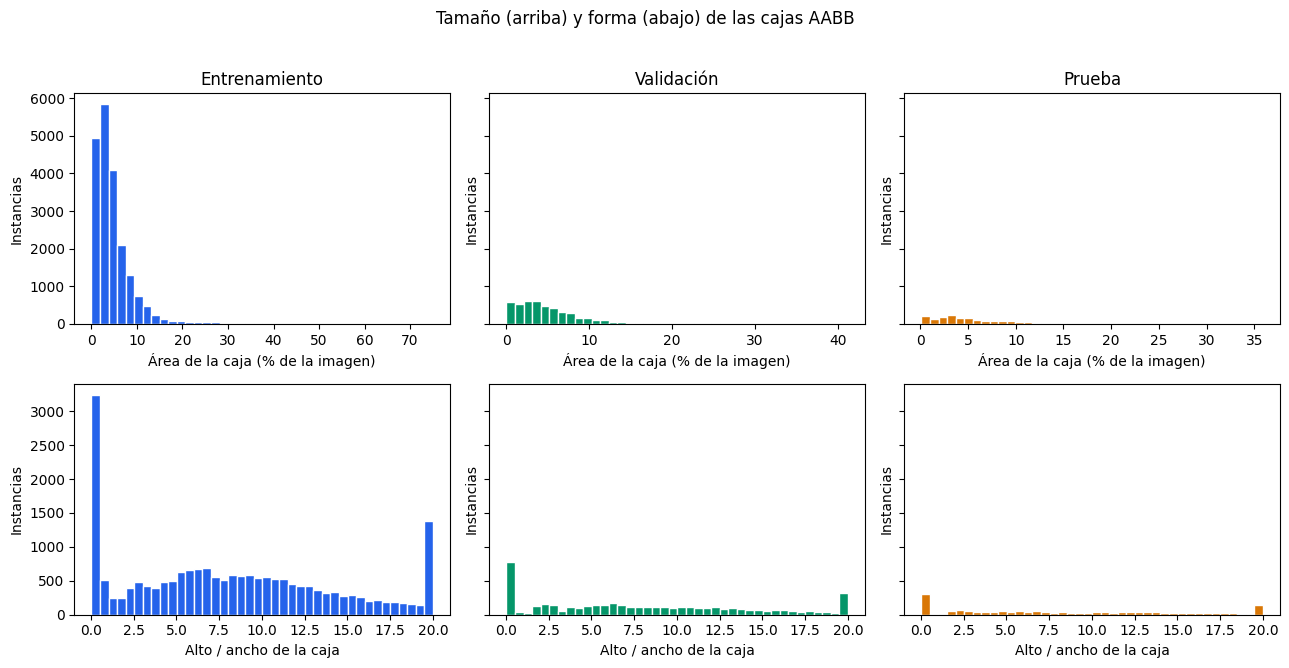

In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PARTICIONES = (
    ("train", "Entrenamiento"),
    ("valid", "Validación"),
    ("test", "Prueba"),
)
LADO_IMAGEN = 640
AREA_CHICA = 32 * 32
AREA_GRANDE = 96 * 96
COLORES = ("#2563eb", "#059669", "#d97706")


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def poligono_desde_linea(linea: str) -> np.ndarray | None:
    partes = linea.split()
    if len(partes) < 7:
        return None
    valores = np.array([float(p) for p in partes[1:]], dtype=float)
    if valores.size % 2 != 0 or valores.size < 6:
        return None
    return valores.reshape(-1, 2)


def medidas_caja(vertices: np.ndarray) -> tuple[float, float, float, float]:
    xmin, ymin = vertices.min(axis=0)
    xmax, ymax = vertices.max(axis=0)
    ancho_rel = max(float(xmax - xmin), 1e-12)
    alto_rel = max(float(ymax - ymin), 1e-12)
    area_rel = ancho_rel * alto_rel
    aspecto = alto_rel / ancho_rel
    return ancho_rel, alto_rel, area_rel, aspecto


def medidas_de_split(directorio_etiquetas: Path) -> dict[str, np.ndarray]:
    anchos, altos, areas, aspectos = [], [], [], []
    if not directorio_etiquetas.is_dir():
        return {
            "ancho_px": np.array([]),
            "alto_px": np.array([]),
            "area_rel": np.array([]),
            "aspecto": np.array([]),
        }
    for etiqueta in directorio_etiquetas.glob("*.txt"):
        for linea in etiqueta.read_text(encoding="utf-8").splitlines():
            linea = linea.strip()
            if not linea or linea.startswith("#"):
                continue
            poligono = poligono_desde_linea(linea)
            if poligono is None:
                continue
            ancho_rel, alto_rel, area_rel, aspecto = medidas_caja(poligono)
            anchos.append(ancho_rel * LADO_IMAGEN)
            altos.append(alto_rel * LADO_IMAGEN)
            areas.append(area_rel)
            aspectos.append(aspecto)
    return {
        "ancho_px": np.array(anchos, dtype=float),
        "alto_px": np.array(altos, dtype=float),
        "area_rel": np.array(areas, dtype=float),
        "aspecto": np.array(aspectos, dtype=float),
    }


def percentil(valores: np.ndarray, p: float) -> float:
    if valores.size == 0:
        return float("nan")
    return float(np.percentile(valores, p))


try:
    directorio_dataset = DIRECTORIO_DATASET
except NameError:
    directorio_dataset = raiz_del_repo() / "dataset"

medidas = []
for carpeta, _titulo in PARTICIONES:
    medidas.append(medidas_de_split(directorio_dataset / carpeta / "labels"))

print(f"Cajas AABB (export {LADO_IMAGEN}×{LADO_IMAGEN})")
print(
    f"{'Partición':16} {'n':>6} {'ancho p50':>10} {'alto p50':>10} "
    f"{'área% p50':>10} {'alto/ancho p50':>15} {'%chico':>8} {'%med':>8} {'%grande':>8}"
)
for (_carpeta, titulo), m in zip(PARTICIONES, medidas):
    area_px = m["area_rel"] * (LADO_IMAGEN ** 2)
    n = int(m["area_rel"].size)
    if n == 0:
        print(f"{titulo:16} {0:6d}")
        continue
    pct_chico = 100 * np.mean(area_px < AREA_CHICA)
    pct_grande = 100 * np.mean(area_px > AREA_GRANDE)
    pct_med = 100 - pct_chico - pct_grande
    area_pct = 100 * percentil(m["area_rel"], 50)
    print(
        f"{titulo:16} {n:6d} {percentil(m['ancho_px'], 50):10.1f} "
        f"{percentil(m['alto_px'], 50):10.1f} {area_pct:10.2f} "
        f"{percentil(m['aspecto'], 50):15.2f} {pct_chico:8.1f} {pct_med:8.1f} {pct_grande:8.1f}"
    )

print("\nPercentiles área relativa (%)")
print(f"{'Partición':16} {'p10':>8} {'p50':>8} {'p90':>8}")
for (_c, titulo), m in zip(PARTICIONES, medidas):
    print(
        f"{titulo:16} {100 * percentil(m['area_rel'], 10):8.2f} "
        f"{100 * percentil(m['area_rel'], 50):8.2f} "
        f"{100 * percentil(m['area_rel'], 90):8.2f}"
    )

print("\nPercentiles alto/ancho")
print(f"{'Partición':16} {'p10':>8} {'p50':>8} {'p90':>8}")
for (_c, titulo), m in zip(PARTICIONES, medidas):
    print(
        f"{titulo:16} {percentil(m['aspecto'], 10):8.2f} "
        f"{percentil(m['aspecto'], 50):8.2f} "
        f"{percentil(m['aspecto'], 90):8.2f}"
    )

figura, ejes = plt.subplots(2, 3, figsize=(13, 6.5), sharey="row")
for col, ((_carpeta, titulo), m, color) in enumerate(zip(PARTICIONES, medidas, COLORES)):
    ejes[0, col].hist(100 * m["area_rel"], bins=40, color=color, edgecolor="white")
    ejes[0, col].set_title(titulo)
    ejes[0, col].set_xlabel("Área de la caja (% de la imagen)")
    ejes[0, col].set_ylabel("Instancias")

    ejes[1, col].hist(
        np.clip(m["aspecto"], 0, 20), bins=40, color=color, edgecolor="white"
    )
    ejes[1, col].set_xlabel("Alto / ancho de la caja")
    ejes[1, col].set_ylabel("Instancias")

figura.suptitle("Tamaño (arriba) y forma (abajo) de las cajas AABB", y=1.02)
figura.tight_layout()
plt.show()


### Lectura: tamaño y forma

Las tres particiones se parecen: mediana de caja ~44–47 px de ancho y ~350–380 px de alto, área ~3,6–4,3 % de la imagen, alto/ancho ~7. Train, valid y test no están sesgados por tamaño; medir en validación es razonable.

Casi todo es **grande** en el criterio COCO (~71–78 %), y apenas un 2–3 % es chico por *área*. Eso engaña: el área es grande porque el lomo es **alto**, no porque sea fácil. La mediana de aspecto 7,4 quiere decir cajas muy angostas. El p10 de aspecto (~0,3) muestra el otro extremo: ~10 % de las cajas son más anchas que altas (fila de libros o AABB holgado). El p90 llega a ~18: tiras de unos 40 px de ancho en 640.

**Riesgos para el objetivo (detectar lomos y leer el título)**

- Detectores AABB y NMS se llevan mal con objetos muy alargados: un lomo fino se fusiona con el vecino o se pierde.
- Un recorte de ~44 px de ancho (y menos si se encoge la caja) deja poco detalle para OCR, sobre todo con texto vertical.
- El mAP “en objetos grandes” puede verse alto y igual fallar en lomos angostos; COCO-large no equivale a recorte legible.
- El 10 % de cajas achatadas mezcla varios títulos en un solo recorte.

**Cómo reducirlos**

- Entrenar e inferir a resolución alta (el export ya es 640; no bajar `imgsz` para ahorrar).
- Para OCR: recortar la banda central, **redimensionar** el crop (p. ej. ancho mínimo 64–128 px) y probar rotación 90° si el texto es vertical.
- No filtrar “objetos chicos” solo por área COCO; si se filtra, usar **ancho mínimo en píxeles**.
- En matching, tratar como *baja confianza* recortes muy anchos (aspecto &lt; 1) o muy angostos con poco texto.


### 3.5 Inclinación y solape

Dos propiedades que no salen del tamaño: si el lomo está **torcido** y si las **cajas se pisan**.

**Inclinación:** ángulo (0°–90°) entre el eje principal del polígono y la vertical. 0° = lomo parado; 90° = acostado. Se usa el polígono, no la caja, para no confundir holgura del AABB con rotación real.

**Solape:** para cada caja AABB, el **máximo IoU** con otra caja de la misma imagen. Un IoU alto entre vecinos hace que el NMS borre un lomo verdadero y que un recorte mezcle dos títulos.

Se reportan percentiles, el porcentaje de cajas con IoU ≥ 0,1 / 0,3 / 0,5, y histogramas **por partición**. Splits parecidos implican que validación representa a train. Requiere `dataset/` y las etiquetas YOLO.


Inclinación respecto de la vertical (grados)
Partición             n      p10      p50      p90    media    %>15°    %>45°
Entrenamiento     20354      0.5      3.4     79.8     18.4     23.7     18.6
Validación         4622      0.4      3.7     78.5     18.0     23.7     17.5
Prueba             1747      0.3      3.7     77.7     18.5     27.6     17.6

Solape AABB: máximo IoU con otra caja de la misma imagen
Partición             n      p10      p50      p90    media    IoU≥0.1    IoU≥0.3    IoU≥0.5
Entrenamiento     20354     0.02     0.24     0.60     0.28       75.6       41.5       18.8
Validación         4622     0.02     0.27     0.64     0.31       76.1       46.2       23.3
Prueba             1747     0.04     0.25     0.70     0.32       79.3       45.0       26.1


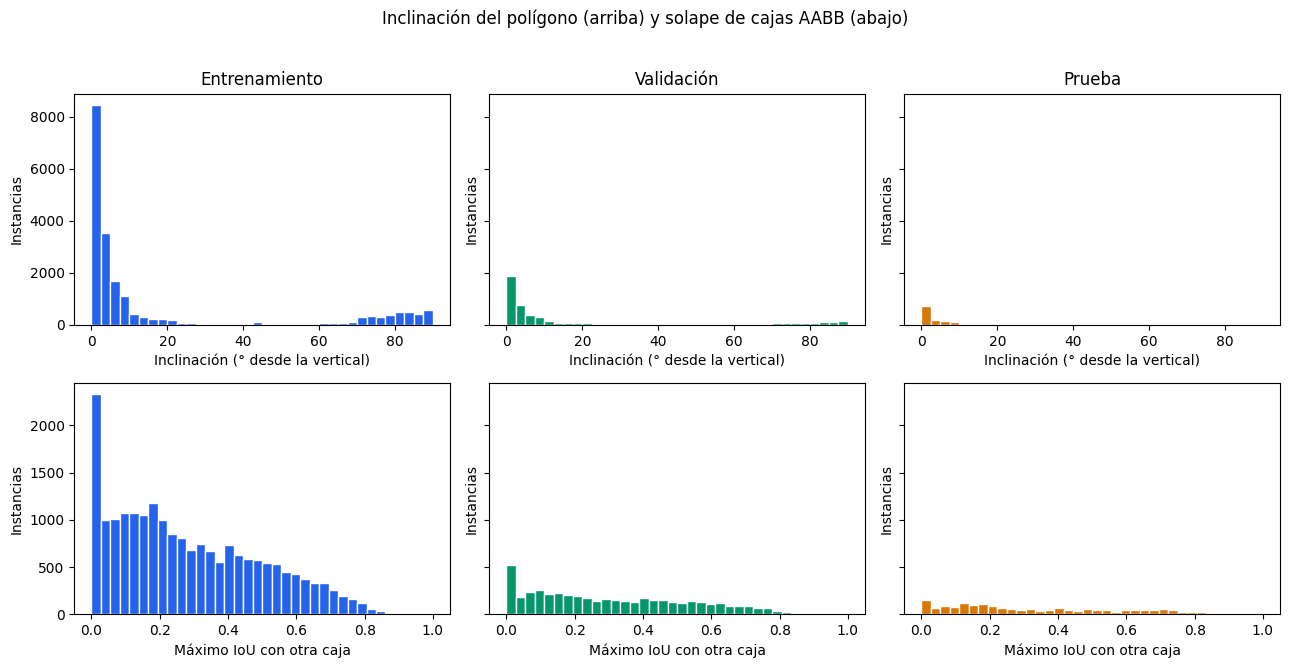

In [9]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

PARTICIONES = (
    ("train", "Entrenamiento"),
    ("valid", "Validación"),
    ("test", "Prueba"),
)
COLORES = ("#2563eb", "#059669", "#d97706")
UMBRALES_IOU = (0.1, 0.3, 0.5)


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def poligono_desde_linea(linea: str) -> np.ndarray | None:
    partes = linea.split()
    if len(partes) < 7:
        return None
    valores = np.array([float(p) for p in partes[1:]], dtype=float)
    if valores.size % 2 != 0 or valores.size < 6:
        return None
    return valores.reshape(-1, 2)


def caja_xyxy(vertices: np.ndarray) -> tuple[float, float, float, float]:
    xmin, ymin = vertices.min(axis=0)
    xmax, ymax = vertices.max(axis=0)
    return float(xmin), float(ymin), float(xmax), float(ymax)


def inclinacion_grados(vertices: np.ndarray) -> float:
    puntos = vertices - vertices.mean(axis=0)
    if len(puntos) < 2:
        return float("nan")
    cov = np.cov(puntos.T)
    if cov.shape != (2, 2) or np.allclose(cov, 0):
        return float("nan")
    _valores, vectores = np.linalg.eigh(cov)
    eje = vectores[:, int(np.argmax(_valores))]
    norma = float(np.linalg.norm(eje)) + 1e-12
    cos_vertical = abs(float(eje[1])) / norma
    return float(np.degrees(np.arccos(np.clip(cos_vertical, 0.0, 1.0))))


def iou_cajas(a: tuple[float, float, float, float], b: tuple[float, float, float, float]) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = max(ax2 - ax1, 0.0) * max(ay2 - ay1, 0.0)
    area_b = max(bx2 - bx1, 0.0) * max(by2 - by1, 0.0)
    union = area_a + area_b - inter
    return inter / union if union > 1e-12 else 0.0


def metricas_split(directorio_etiquetas: Path) -> dict[str, np.ndarray]:
    inclinaciones: list[float] = []
    max_ious: list[float] = []
    if not directorio_etiquetas.is_dir():
        return {"inclinacion": np.array([]), "max_iou": np.array([])}
    for etiqueta in directorio_etiquetas.glob("*.txt"):
        poligonos: list[np.ndarray] = []
        for linea in etiqueta.read_text(encoding="utf-8").splitlines():
            linea = linea.strip()
            if not linea or linea.startswith("#"):
                continue
            poligono = poligono_desde_linea(linea)
            if poligono is not None:
                poligonos.append(poligono)
        cajas = [caja_xyxy(p) for p in poligonos]
        for poligono in poligonos:
            angulo = inclinacion_grados(poligono)
            if not np.isnan(angulo):
                inclinaciones.append(angulo)
        n = len(cajas)
        for i in range(n):
            mejor = 0.0
            for j in range(n):
                if i == j:
                    continue
                mejor = max(mejor, iou_cajas(cajas[i], cajas[j]))
            max_ious.append(mejor)
    return {
        "inclinacion": np.array(inclinaciones, dtype=float),
        "max_iou": np.array(max_ious, dtype=float),
    }


def percentil(valores: np.ndarray, p: float) -> float:
    if valores.size == 0:
        return float("nan")
    return float(np.percentile(valores, p))


try:
    directorio_dataset = DIRECTORIO_DATASET
except NameError:
    directorio_dataset = raiz_del_repo() / "dataset"

resultados = [
    metricas_split(directorio_dataset / carpeta / "labels") for carpeta, _t in PARTICIONES
]

print("Inclinación respecto de la vertical (grados)")
print(f"{'Partición':16} {'n':>6} {'p10':>8} {'p50':>8} {'p90':>8} {'media':>8} {'%>15°':>8} {'%>45°':>8}")
for (_c, titulo), m in zip(PARTICIONES, resultados):
    ang = m["inclinacion"]
    n = int(ang.size)
    if n == 0:
        print(f"{titulo:16} {0:6d}")
        continue
    print(
        f"{titulo:16} {n:6d} {percentil(ang, 10):8.1f} {percentil(ang, 50):8.1f} "
        f"{percentil(ang, 90):8.1f} {float(ang.mean()):8.1f} "
        f"{100 * np.mean(ang > 15):8.1f} {100 * np.mean(ang > 45):8.1f}"
    )

print("\nSolape AABB: máximo IoU con otra caja de la misma imagen")
encabezado_iou = " ".join(f"{'IoU≥'+str(u):>10}" for u in UMBRALES_IOU)
print(f"{'Partición':16} {'n':>6} {'p10':>8} {'p50':>8} {'p90':>8} {'media':>8} {encabezado_iou}")
for (_c, titulo), m in zip(PARTICIONES, resultados):
    iou = m["max_iou"]
    n = int(iou.size)
    if n == 0:
        print(f"{titulo:16} {0:6d}")
        continue
    pcts = " ".join(f"{100 * np.mean(iou >= u):10.1f}" for u in UMBRALES_IOU)
    print(
        f"{titulo:16} {n:6d} {percentil(iou, 10):8.2f} {percentil(iou, 50):8.2f} "
        f"{percentil(iou, 90):8.2f} {float(iou.mean()):8.2f} {pcts}"
    )

figura, ejes = plt.subplots(2, 3, figsize=(13, 6.5), sharey="row")
for col, ((_c, titulo), m, color) in enumerate(zip(PARTICIONES, resultados, COLORES)):
    ejes[0, col].hist(m["inclinacion"], bins=36, range=(0, 90), color=color, edgecolor="white")
    ejes[0, col].set_title(titulo)
    ejes[0, col].set_xlabel("Inclinación (° desde la vertical)")
    ejes[0, col].set_ylabel("Instancias")

    ejes[1, col].hist(m["max_iou"], bins=36, range=(0, 1), color=color, edgecolor="white")
    ejes[1, col].set_xlabel("Máximo IoU con otra caja")
    ejes[1, col].set_ylabel("Instancias")

figura.suptitle("Inclinación del polígono (arriba) y solape de cajas AABB (abajo)", y=1.02)
figura.tight_layout()
plt.show()


### Lectura: inclinación y solape

Los tres splits se parecen. La **mediana de inclinación es ~3,5–3,7°**: la mayoría de los lomos están casi verticales. La **media (~18°)** y el **p90 (~78°)** muestran una cola: ~18 % superan 45° (libros muy torcidos o acostados). No es un dataset “todo inclinado”; es uno **bimodal** (parado vs. muy rotado).

El solape de cajas sí es el caso típico. En validación, el **máximo IoU mediano es 0,27** y **el 76 %** de las cajas pisa a otra con IoU ≥ 0,1; **el 23 %** llega a IoU ≥ 0,5. Eso encaja con ~16 lomos por foto y AABB holgados (ocupación 0,54).

**Riesgos para el objetivo (detectar lomos y leer el título)**

- Un NMS a IoU 0,5 puede borrar un lomo verdadero que convive con el vecino (un cuarto de las cajas ya se pisan así en el GT).
- Cajas superpuestas → el recorte mezcla dos lomos; el OCR y el matching atribuyen el título al libro equivocado.
- El ~18 % muy inclinado genera AABB enormes (poca ocupación) y texto en diagonal o de costado, peor para OCR alineado al eje.
- Un mAP global puede esconder fallos justo en estantes densos y en lomos torcidos.

**Cómo reducirlos**

- NMS más permisivo o *soft-NMS* (no tirar predicciones con IoU 0,45–0,55).
- Recorte: encoger el AABB o usar máscara; si la inclinación es alta, rotar el crop al eje del lomo antes del OCR.
- EasyOCR con detección de orientación; no asumir texto vertical perfecto.
- Matching con *baja confianza* si el recorte es ancho, hay poco texto o conviven dos cadenas distintas.
- Reportar métricas también en el subconjunto denso / inclinado, no solo el promedio de validación.
